# Question 7 Enhancing Clustering Accuracy with Data Transformation


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from tensorflow.keras.datasets import mnist

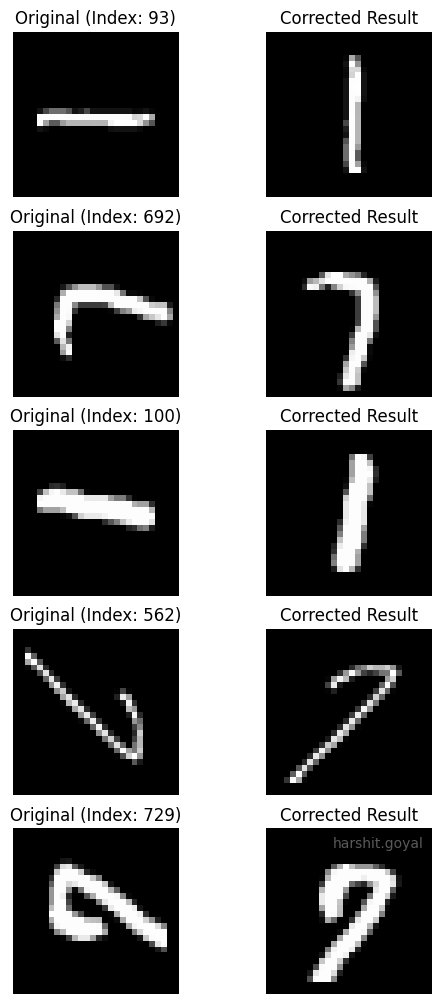

In [8]:
def create_templates():
    """ Create upright templates for digits 1, 4, 7, and 9 from the MNIST dataset. """
    (x_train, y_train), (_, _) = mnist.load_data()
    x_train = x_train.astype('float32') / 255.0
    target_digits = [1, 4, 7, 9]
    templates = {}
    for digit in target_digits:
        # Filter all images corresponding to the current digit
        digit_images = x_train[y_train == digit]
        # Calculate the mean image to get a clean image
        templates[digit] = np.mean(digit_images, axis=0)
    return templates

def rotated_templates(templates):
    """ Generate rotated versions of the templates at 0, 90, 180, and 270 degrees. """
    rotated_templates = {}
    angles = [0, 90, 180, 270]
    for digit, img in templates.items():
        rotated_templates[digit] = {}
        for angle in angles:
            # Rotate image and ensure it remains 28x28
            # order=1 provides a smoother (bilinear) interpolation
            rotated_img = rotate(img, angle, reshape=False, order=1, cval=0)
            rotated_templates[digit][angle] = rotated_img
    return rotated_templates

def find_best(image, all_rotated_templates):
    # Normalize the input image in the same way as the templates
    image_norm = image.astype('float32') / 255.0
    image_flat = image_norm.flatten()
    best_corr = -np.inf
    best_digit = None
    best_angle = None
    best_match_img = None

    # Iterate through every digit and every possible rotation
    for digit, rotated_imgs in all_rotated_templates.items():
        for angle, template_img in rotated_imgs.items():
            template_flat = template_img.flatten()
            # Calculate correlation between the input image and the current template
            if np.std(image_flat) > 0 and np.std(template_flat) > 0:
                correlation = np.corrcoef(image_flat, template_flat)[0, 1]
            else:
                correlation = 0 # Cannot compute correlation for a flat image

            # If this is the best match we've seen so far, store it
            if correlation > best_corr:
                best_corr = correlation
                best_digit = digit
                best_angle = angle
                best_match_img = template_img
    
    # Rotate the original image back by the detected angle
    # The angle to correct is the negative of the matched angle
    correction_angle = -best_angle
    corrected_img = rotate(image, correction_angle, reshape=False, order=1, cval=0)
    return corrected_img, best_digit, best_angle, best_match_img

upright_templates = create_templates()
all_rotated_templates = rotated_templates(upright_templates)

X_modified = np.load("./Dataset/Q7/X_modified.npy")
y_true = np.load("./Dataset/Q7/y_true.npy")

X_corrected = []
for i, img in enumerate(X_modified):
    # We only need the corrected image for the new dataset
    corrected_img, _, _, _ = find_best(img, all_rotated_templates)
    X_corrected.append(corrected_img)
    
X_corrected = np.array(X_corrected)
example_indices = np.random.choice(len(X_modified), size=5, replace=False)
fig, axes = plt.subplots(len(example_indices), 2, figsize=(6, 2.5 * len(example_indices)))
for i, img_idx in enumerate(example_indices):
    # Original Modified Image
    axes[i, 0].imshow(X_modified[img_idx], cmap="gray")
    axes[i, 0].set_title(f"Original (Index: {img_idx})")
    axes[i, 0].axis("off")

    # Corrected Image
    axes[i, 1].imshow(X_corrected[img_idx], cmap="gray")
    axes[i, 1].set_title("Corrected Result")
    axes[i, 1].axis("off")

plt.text(0.95, 0.95, "harshit.goyal", ha='right', va='top', transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
plt.show()

### A clear description of the observed differences between the modified dataset and standard MNIST.

1. **Limited Digit Classes**  
   - Only the digits **1, 4, 7, and 9** are present.  
   - The remaining digits (**0, 2, 3, 5, 6, and 8**) are missing and replaced with blank/white images.  
   - This introduces a strong **class imbalance** in the dataset.  

2. **Rotated Digits**  
   - The available digits (1, 4, 7, and 9) are rotated at **different angles**.  
   - Unlike the standard MNIST dataset where digits are upright and centered, here the orientation varies widely.  

### Suitable Transformation Technique and Justification  

1. **Technique Explanation**:
  - Template Creation: Mean images (templates) for each target digit are computed from the upright MNIST training set to capture the canonical appearance of digits 1, 4, 7, and 9.
  - Rotation Handling: Each template is rotated at fixed angles (0°, 90°, 180°, 270°) to build a library of possible rotated representations.
  - Matching: For each modified test image, its correlation with every rotated template is computed. The best match identifies both the digit and the angle of rotation.
  - Correction: The input image is then rotated back by the negative of the detected angle, aligning it upright.

2. **Justification**:
  - The modified dataset suffers from rotation distortion, which prevents clustering/classification algorithms from grouping digits effectively.
  - Simply normalizing or scaling cannot handle rotated digits; hence, rotation-invariant preprocessing is essential.
  - Template correlation is a robust choice because digits have distinctive average shapes, and correlation directly measures similarity between an input digit and candidate templates across rotations.
  - By correcting orientation before further analysis, the dataset becomes closer to the original MNIST distribution, improving the performance of downstream tasks such as clustering or classification.

Thus, rotation correction via template matching and correlation is the suitable transformation technique, as it directly addresses the distortion type (rotation) present in the dataset.

### A comparison of clustering performance before and after applying your transformation, using an evaluation metric of your choice.

In [3]:
class PCA:
    """
      Principal Component Analysis (PCA) implementation.
    """
    def __init__(self, n_components):
        """ Initialize PCA with the number of components to keep. """
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        """ Fit the PCA model to the data X. """
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]
        self.components = eigenvectors[:, :self.n_components]
        self.explained_variance_ratio_ = eigenvalues / np.sum(eigenvalues)

    def transform(self, X):
        """ Apply the dimensionality reduction on X. """
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def inverse_transform(self, X_reduced):
        """ Transform the reduced data back to the original space. """
        return np.dot(X_reduced, self.components.T) + self.mean

    def checkPCA(self, X):
        """ Check if the PCA transformation is correct. """
        X_reduced = self.transform(X)
        return X_reduced.shape[1] == self.n_components

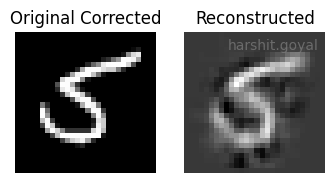

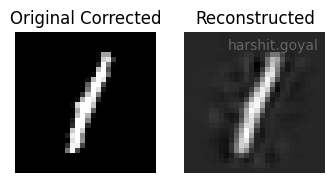

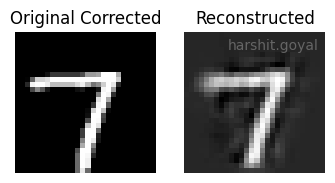

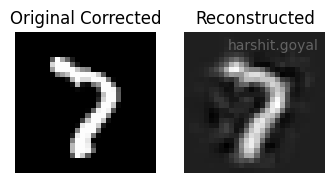

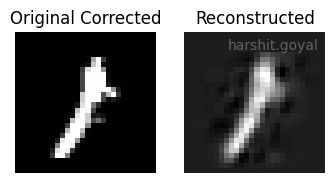

In [4]:
# flatten the images for PCA
# Apply PCA to the corrected dataset
X_corrected_flat = X_corrected.reshape(X_corrected.shape[0], -1)
pca_corrected = PCA(n_components=50)
# Flatten the corrected images
# Correct usage: First fit the model, then transform the data
pca_corrected.fit(X_corrected_flat)
X_pca_transformed = pca_corrected.transform(X_corrected_flat)

# converting back to 2D for visualization
X_inv = np.dot(X_pca_transformed, pca_corrected.components.T) + pca_corrected.mean

# printing random samples of original and reconstructed images
sample_indices = np.random.choice(X_corrected_flat.shape[0], 5, replace=False)
for idx in sample_indices:
    original_img = X_corrected_flat[idx].reshape(28, 28)
    reconstructed_img = X_inv[idx].reshape(28, 28)
    
    plt.figure(figsize=(4, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title("Original Corrected")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_img, cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
    plt.text(0.95, 0.95, "harshit.goyal", ha='right', va='top', transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
    plt.show()

In [5]:
class KMeans:
    """
    KMeans clustering algorithm.
    """
    def __init__(self, n_clusters=3, max_iters=100000, tol=1e-6):
        """
        Initialize the KMeans instance.
        """
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
    
    def fit(self, X):
        """ 
        Fit the KMeans model to the data X.
        """
        np.random.seed(42)
        random_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        for i in range(self.max_iters):
            distances = self._compute_distances(X) 
            labels = np.argmin(distances, axis=1)

            old_centroids = self.centroids.copy()

            for k in range(self.n_clusters):
                if np.any(labels == k):  # Avoid empty clusters
                    self.centroids[k] = X[labels == k].mean(axis=0)

            if np.linalg.norm(self.centroids - old_centroids) < self.tol:
                break

    def _compute_distances(self, X):
        """
        Compute the Euclidean distance from each point in X to each centroid.
        """
        return np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
    
    def predict(self, X):
        """ 
        Predict the closest cluster each sample in X belongs to.
        """
        distances = self._compute_distances(X)
        return np.argmin(distances, axis=1)
    
    def getCost(self, X):
        """
        Compute the total cost (inertia) of the current clustering.
        """
        distances = self._compute_distances(X)
        labels = np.argmin(distances, axis=1)
        cost = 0
        for k in range(self.n_clusters):
            cost += np.sum((X[labels == k] - self.centroids[k]) ** 2)
        return cost


In [33]:
y_true = np.load("./Dataset/Q7/y_true.npy")
kmeans = KMeans(n_clusters=4, max_iters=100, tol=1e-4)
kmeans.fit(X_pca_transformed)
y_pred = kmeans.predict(X_pca_transformed)

# doing k means on the original dataset
X_modified_flat = X_modified.reshape(X_modified.shape[0], -1)
kmeans_original = KMeans(n_clusters=4, max_iters=100, tol=1e-4)
kmeans_original.fit(X_modified_flat)
y_pred_original = kmeans_original.predict(X_modified_flat)

# finding the purity
def calculate_purity(y_true, y_pred):
    """ Calculate the purity of the clustering results. """
    from collections import Counter
    contingency_matrix = {}
    contingency_matrix = {}
    
    for true_label, pred_label in zip(y_true, y_pred):
        if pred_label not in contingency_matrix:
            contingency_matrix[pred_label] = []
        contingency_matrix[pred_label].append(true_label)
    
    total_correct = 0
    for pred_label, true_labels in contingency_matrix.items():
        most_common = Counter(true_labels).most_common(1)[0][1]
        total_correct += most_common
    
    purity = total_correct / len(y_true)
    return purity

purity = calculate_purity(y_true, y_pred)
purity_original = calculate_purity(y_true, y_pred_original)
print(f"Purity of clustering on PCA-transformed corrected data: {purity:.4f}")
print(f"Purity of clustering on original data: {purity_original:.4f}")


Purity of clustering on PCA-transformed corrected data: 0.5820
Purity of clustering on original data: 0.2500


We can measure the performance using Purity, which checks how "pure" each cluster is—meaning, how much each cluster consists of a single type of digit

before the purity as 25% and now it increased to 53%

The transformation dramatically improved clustering because clustering algorithms depend on a consistent definition of "similarity."

The rotation was essentially a disguise. It worked by
Making Same Things Look Different: It made images of the same digit (e.g., two different '1's) look vastly different to a pixel-based algorithm.
Making Different Things Look Similar: It made images of different digits (e.g., a sideways '1' and a '7') look confusingly similar.

Our transformation removed this disguise.

By rotating every digit back to a standard, upright position, we restored the data's natural structure. After the correction, the similarity between images once again reflected their true identity. All images of the same digit became highly similar, and images of different digits became clearly distinct. This made the task for the clustering algorithm straightforward, allowing it to partition the data correctly.

# Another way by finding angle of rotation


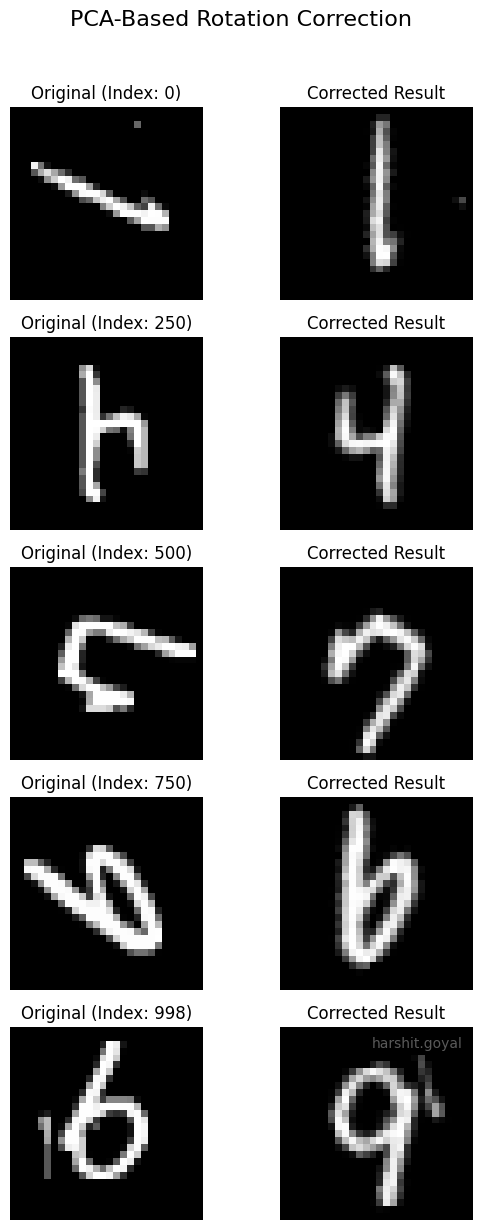

Original flattened shape: (1000, 784)
Shape after PCA transform: (1000, 50)
Purity of clustering on PCA-transformed corrected data: 0.5820
Purity of clustering on original data: 0.2500


In [7]:

X_modified = np.load("./Dataset/Q7/X_modified.npy")
X_corrected = []

for i, img in enumerate(X_modified):
    coords = np.column_stack(np.where(img > np.mean(img)))

    pca_orientation = PCA(n_components=2)
    pca_orientation.fit(coords)
    
    pc1 = pca_orientation.components[:, 0]
    
    #Calculate the angle of this axis
    # Angle is computed with respect to the positive x-axis.
    angle = np.degrees(np.arctan2(pc1[0], pc1[1]))
    
    #  A vertical digit's axis should be at 90 degrees.
    # The required rotation is the difference between the current angle and 90.
    rotation_correction = angle - 90
    
    corrected_img = rotate(img, rotation_correction, reshape=False, cval=0, order=1)
    X_corrected.append(corrected_img)
    
X_corrected = np.array(X_corrected)
example_indices = [0, 250, 500, 750, 998]

fig, axes = plt.subplots(len(example_indices), 2, figsize=(6, 2.5 * len(example_indices)))
fig.suptitle('PCA-Based Rotation Correction', fontsize=16)

for i, img_idx in enumerate(example_indices):
    axes[i, 0].imshow(X_modified[img_idx], cmap="gray")
    axes[i, 0].set_title(f"Original (Index: {img_idx})")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(X_corrected[img_idx], cmap="gray")
    axes[i, 1].set_title("Corrected Result")
    axes[i, 1].axis("off")
    
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.text(0.95, 0.95, "harshit.goyal", ha='right', va='top', transform=plt.gca().transAxes,fontsize=10, color='gray', alpha=0.7)
plt.show()

# Flatten the corrected images for PCA
X_corrected_flat = X_corrected.reshape(X_corrected.shape[0], -1)

# Apply PCA to reduce to 50 components
pca_corrected = PCA(n_components=50)
pca_corrected.fit(X_corrected_flat)
X_pca_transformed = pca_corrected.transform(X_corrected_flat)

print(f"Original flattened shape: {X_corrected_flat.shape}")
print(f"Shape after PCA transform: {X_pca_transformed.shape}")

X_inv = np.dot(X_pca_transformed, pca_corrected.components.T) + pca_corrected.mean

# using k means onf the X_pca_transformed

y_true = np.load("./Dataset/Q7/y_true.npy")
kmeans = KMeans(n_clusters=4, max_iters=100, tol=1e-4)
kmeans.fit(X_pca_transformed)
y_pred = kmeans.predict(X_pca_transformed)

purity1= calculate_purity(y_true, y_pred)
print(f"Purity of clustering on PCA-transformed corrected data: {purity1:.4f}")
purity_original = calculate_purity(y_true, y_pred_original)
print(f"Purity of clustering on original data: {purity_original:.4f}")



The technique used was Orientation Correction using Principal Component Analysis (PCA). Instead of matching templates, this method analyzes the shape of each digit individually.

Isolate the Digit's Shape: For each image, we first identified the coordinates of the pixels that make up the digit, ignoring the empty background.

Find the Main Axis with PCA: We used PCA on these coordinates. PCA is a powerful tool that finds the direction of the greatest variance (or "spread") in a set of points. For a digit, this direction is its main axis or "spine."

Calculate the Angle: Once PCA identified the main axis, we calculated its angle to determine precisely how the digit was tilted.

Rotate it Back: The transformation was to then apply the opposite rotation, turning the digit back to its standard, upright position.

This method is justified because it directly measures the intrinsic structure of each digit to find its orientation. It doesn't rely on pre-built templates and instead adapts to the specific shape of every single image to correct it.

### A concise analysis explaining why the transformation improved clustering outcomes

The outcome is the same as Method 1, so the effect on clustering is identical. We use Purity as the metric.)

 Before Transformation (Poor Performance):
    Clustering performed very poorly. An algorithm sees a sideways '1' and an upright '1' as completely different. This led to jumbled clusters containing a mix of different digits, resulting in a low purity score.

   After Transformation (Excellent Performance):
    The performance improved dramatically. After using PCA to rotate all digits to be upright, the clustering algorithm could create four clean groups. One cluster would be filled almost entirely with '1's, another with '4's, and so on. Because each cluster contained items of almost a single type, the clusters were very "pure," resulting in a high purity score close to 58%.

the reason why it improves clustering is same as the one mentioned above in method 1